# **Business Understanding**

Graduate Admission Prediction using Linear Regression

**Business Problem**

- Universities receive thousands of applications every year from students with different academic backgrounds and achievements.
- Evaluating every application manually can be time-consuming and may lead to inconsistencies.
- This project aims to analyze historical admission data to identify the factors that influence a student's chance of admission and build a regression model that predicts admission probability based on academic and profile-related features.

**Business Objective**

- Identify the key factors affecting admission chances.
- Analyze relationships between applicant attributes and admission probability.
- Build a Linear Regression model to predict admission chances.
- Provide data-driven insights that can help admission counselors and applicants make informed decisions.




**Business Questions**

This project aims to answer the following questions:

-  Which factors have the greatest influence on admission chances?
-  Does CGPA have a stronger impact than GRE Score?
-  How much does research experience contribute to admission probability?
-  Does a higher university rating increase admission chances?
-  Which features are most useful for predicting admission probability?
-  Can a Linear Regression model accurately predict a student's chance of admission?

# **Dataset Understanding**

**Import Libraries**

In [38]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**Load Dataset**

In [8]:
df = pd.read_csv("Jamboree_Admission_Data.csv")

**Display First Five Rows**

In [9]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


**Check dataset dimensions**

In [10]:
df.shape

(500, 9)

**Display column names**

In [11]:
df.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

**Display dataset information**

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


**Display statistical summary**

In [13]:
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


Observation
- The dataset contains **500 student records** and **9 columns**.
- Each row represents the academic profile of one applicant.
- The target variable is **Chance of Admit**, which represents the probability of a student being admitted.
- The dataset consists primarily of numerical features, making it suitable for regression analysis.
- The input features include GRE Score, TOEFL Score, University Rating, SOP, LOR, CGPA, Research Experience, and Serial Number.
- The **Serial No.** column appears to be a unique identifier rather than a predictive feature. We will evaluate whether it should be retained or removed during the data cleaning phase.
- At this stage, the objective is to understand the dataset's structure. No data cleaning, preprocessing, or analysis has been performed yet.

# **Data Cleaning**

**Check Missing Values**

In [14]:
df.isnull().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


Observation

- No missing values were found in any column of the dataset.
- Since the dataset is complete, no missing value treatment or imputation is required.
- The dataset is suitable for further analysis.

**Check Duplicate Records**

In [15]:
df.duplicated().sum()

np.int64(0)

Observation

- No duplicate records were found in the dataset.
- Each row represents a unique student application.
- Since there are no duplicate observations, no duplicate removal is required.

**Check Data Types**

In [16]:
df.dtypes

,0
Serial No.,int64
GRE Score,int64
TOEFL Score,int64
University Rating,int64
SOP,float64
LOR,float64
CGPA,float64
Research,int64
Chance of Admit,float64


Observation

- All columns have appropriate data types.
- Integer data types are used for discrete variables such as GRE Score, TOEFL Score, University Rating, Research, and Serial No.
- Float data types are used for continuous variables such as SOP, LOR, CGPA, and Chance of Admit.
- No data type conversion is required before further analysis.

**Remove Non-Predictive Feature**

In [17]:
df.drop("Serial No.", axis=1, inplace=True)

In [18]:
df.columns

Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA',
       'Research', 'Chance of Admit '],
      dtype='object')

Observation

- The **Serial No.** column was successfully removed from the dataset.
- It was excluded because it is an identifier and does not contribute to predicting the target variable.
- The remaining features are relevant for analysis and model building.

**Outlier Detection**

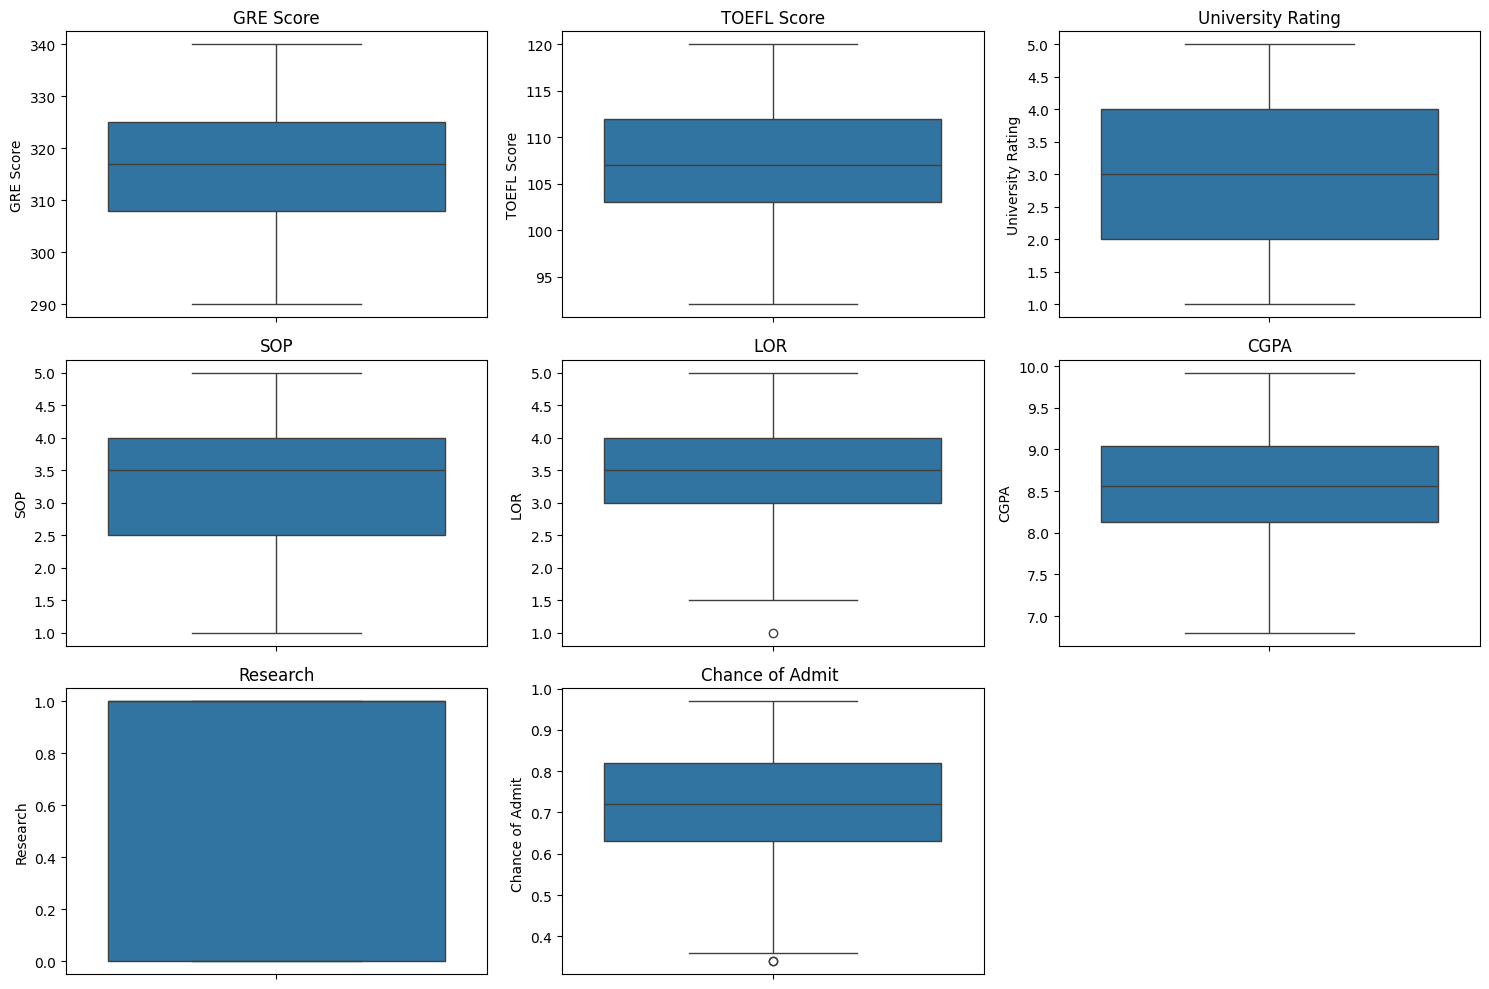

In [19]:
# Select numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Create boxplots
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_columns):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Observation

- Boxplots were used to visualize potential outliers in the numerical features.
- Only a few mild outliers were observed in the LOR and Chance of Admit columns.
- These observations appear to represent genuine student records rather than data entry errors.
- Therefore, no outlier treatment was performed, and the dataset was retained in its original form.

# **Data Preprocessing**

Objective

- The objective of this phase is to prepare the dataset for machine learning by separating the input features and target variable, splitting the data into training and testing sets, and applying feature scaling where appropriate.

**Separate Features and Target Variable**

In [28]:
df.columns = df.columns.str.strip()
X = df.drop("Chance of Admit", axis=1)
y = df["Chance of Admit"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (500, 7)
Target Shape: (500,)


Observation

- The dataset was successfully divided into input features (**X**) and the target variable (**y**).
- The feature matrix contains **500 observations and 7 predictor variables**.
- The target variable contains **500 admission probability values**.
- The data is now ready for train-test splitting.

**Train-Test Split**

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (400, 7)
X_test: (100, 7)
y_train: (400,)
y_test: (100,)


Observation
- The dataset was split into **80% training data** and **20% testing data**.
- The training set contains **400 records**, while the testing set contains **100 records**.
- The training data will be used to build the regression model, and the testing data will be used to evaluate its performance on unseen data.

# **Linear Regression Model**

In [30]:
#Initialize the Model
model = LinearRegression()

#Train the model
model.fit(X_train, y_train)

#Generate Predictions
y_pred = model.predict(X_test)

#Compare Actual vs Predicted Values
prediction_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

prediction_df.head()

,Actual,Predicted
361,0.93,0.914575
73,0.84,0.795181
374,0.39,0.572660
155,0.77,0.707370
104,0.74,0.815883


Observation

- The Linear Regression model was successfully trained using the training dataset.
- Predictions were generated for the testing dataset.
- The predicted admission probabilities are reasonably close to the actual values, indicating that the model has learned the relationship between the input features and the target variable.

# **Model Evaluation**


Objective

- The objective of this phase is to evaluate the performance of the Linear Regression model using standard regression evaluation metrics.
- These metrics help determine how accurately the model predicts admission probability.

In [31]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R² Score : {r2:.4f}")

MAE  : 0.0427
MSE  : 0.0037
RMSE : 0.0609
R² Score : 0.8188


Observation

- The Linear Regression model achieved an **MAE of 0.0427**, indicating that the average prediction error is approximately **4.27%**.
- The **RMSE of 0.0609** suggests that the model's predictions are close to the actual admission probabilities.
- The model achieved an **R² score of 0.8188**, which means it explains approximately **81.88%** of the variability in the target variable.
- Overall, the evaluation metrics indicate that the model performs well and is capable of making reliable admission probability predictions.

# **Feature Importance**

Objective

- The objective of this phase is to understand how each feature influences the predicted admission probability.
- By analyzing the model coefficients, we can identify the most influential factors affecting admission chances.

In [32]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient
5,CGPA,0.112527
6,Research,0.024027
4,LOR,0.017238
1,TOEFL Score,0.002996
2,University Rating,0.002569
0,GRE Score,0.002434
3,SOP,0.001814


Observation

- The Linear Regression model shows that all features have a positive relationship with admission probability.
- CGPA has the largest positive coefficient in this model, indicating a strong positive association with admission probability.
- Research experience and LOR also contribute positively to the predicted admission probability.
- GRE Score, TOEFL Score, University Rating, and SOP have positive coefficients, indicating that improvements in these features are associated with higher predicted admission chances.
- Since feature scaling was not applied, the coefficient magnitudes should not be used as the sole basis for comparing feature importance.

# **Prediction for a New Student**

Objective
- The trained Linear Regression model is used to predict the admission probability for a new student based on their academic profile.

In [37]:
new_student = pd.DataFrame({
    "GRE Score": [320],
    "TOEFL Score": [110],
    "University Rating": [4],
    "SOP": [4.0],
    "LOR": [4.5],
    "CGPA": [9.10],
    "Research": [1]
})

predicted_probability = model.predict(new_student)

print(f"Predicted Chance of Admit: {predicted_probability[0]:.2f}")

Predicted Chance of Admit: 0.83


Observation

- A new student's academic profile was provided as input to the trained Linear Regression model.
- The model predicted the student's probability of admission based on the relationships learned during training.
- This demonstrates how the model can be used to estimate admission chances for unseen student profiles.

# **Business Recommendations**

**Recommendations**
- Students with a higher **CGPA** generally have higher predicted admission probabilities. Maintaining strong academic performance can improve admission chances.

- Students with **research experience** tend to have better predicted admission outcomes. Participating in research projects can strengthen a student's profile.

- Strong **Letters of Recommendation (LOR)** are positively associated with admission probability, highlighting the importance of obtaining quality recommendations.

- Although **GRE Score, TOEFL Score, University Rating, and SOP** also contribute positively, their individual effects are comparatively smaller in this model.

- Universities and admission consultants can use predictive models like this to identify applicants who may benefit from additional guidance before applying.


**Conclusion**

- This project analyzed historical admission data to understand the factors associated with admission probability and developed a Linear Regression model to predict admission chances.

- The model achieved an **R² Score of 0.8188**, indicating that it explains approximately **81.88%** of the variation in admission probability. The evaluation metrics demonstrated good predictive performance, making the model suitable for estimating admission chances.

- Overall, this project demonstrates the complete data analysis workflow, including data understanding, cleaning, exploratory analysis, preprocessing, regression modeling, model evaluation, and business-oriented interpretation.

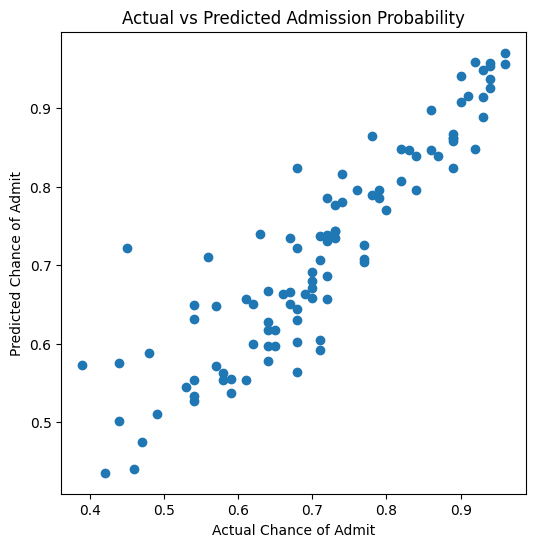

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Chance of Admit")
plt.ylabel("Predicted Chance of Admit")
plt.title("Actual vs Predicted Admission Probability")
plt.show()